In [51]:
import numpy as np


class LogisticRegression:
    def __init__(self, lr=0.1, C=1, num_iter=1000):
        self.lr = lr
        self.C = C
        self.num_iter = num_iter
        self.losses = []

    def sigmoid_usual(self, z):
        return 1 / (1 + np.exp(-z))

    def sigmoid(self, z):
        z = np.array(z, dtype=float)

        positive = z >= 0
        negative = ~positive

        out = np.empty_like(z, dtype=float)

        out[positive] = 1 / (1 + np.exp(-z[positive]))
        out[negative] = np.exp(z[negative]) / (1 + np.exp(z[negative]))

        return out

    def loss(self, probs, y, n):
        eps = 1e-15
        probs = np.clip(probs, eps, 1 - eps)

        loss = -(1 / n) * np.sum(y * np.log(probs) + (1 - y) * np.log(1 - probs))

        return loss

    def gradients(self, n, X, y, logits, metrics="neg_log_loss"):
        if metrics == "neg_log_loss":
            return {
                "weights": (1 / n) * np.matmul(X.T, (logits - y))
                + (1 / self.C) * self.weights,
                "bias": (1 / n) * sum(logits - y),
            }

    def params_renew(self, weights, bias, gradient_weights, gradient_bias):
        weights = weights.copy()  # to not change original weights

        weights -= np.dot(self.lr, gradient_weights)
        bias -= np.dot(self.lr, gradient_bias)
        return weights, bias

    def fit(self, X, y, epsilon=1e-6):
        prev_loss = float("inf")
        self.weights = np.zeros(X.shape[1])
        self.bias = 0
        n = X.shape[0]

        for i in range(self.num_iter):
            logits = np.matmul(X, self.weights) + self.bias
            probs = self.sigmoid(logits)

            grads = self.gradients(n, X, y, probs)
            gradient_weights = grads["weights"]
            gradient_bias = grads["bias"]

            new_weights, new_bias = self.params_renew(
                self.weights, self.bias, gradient_weights, gradient_bias
            )

            loss = self.loss(probs, y, n)
            self.losses.append(loss)
            if abs(prev_loss - loss) < epsilon:
                print(f"Stopped on iteration {i}")
                break
            self.weights, self.bias = new_weights, new_bias
            prev_loss = loss

    
    def predict(self, X_test):
        probabilities = self.sigmoid(self.bias + np.dot(X_test, self.weights))
        classes = (probabilities >= 0.5).astype(int)
        return classes

    def predict_proba(self, X_test):
        p1 = self.sigmoid(self.bias + np.dot(X_test, self.weights))
        p0 = 1 - p1
        return np.vstack([p0, p1]).T

In [52]:
#Learning linear regression models using GD, while sklearn finds analytical solution
#    TODO: ADD SGD and Batch SGD

class Regression:
    def __init__(self, lr=0.001, num_iter=1000):
        self.lr = lr
        self.num_iter = num_iter
        self.weights = np.array([])
        self.bias = 0
        self.losses = []
        
    def __str__(self):
        return self.__class__.__name__
    
    def __repr__(self):
        return self.__class__.__name__


    def params_renew(self, weights, bias, gradient_weights, gradient_bias):
        weights = weights.copy()  # to not change original weights

        weights -= np.dot(self.lr, gradient_weights)
        bias -= np.dot(self.lr, gradient_bias)
        return weights, bias
    
    def fit(self, X, y, epsilon=1e-6):
        prev_loss = float("inf")
        self.weights = np.zeros(X.shape[1])
        self.bias = 0
        n = X.shape[0]
        
        for i in range(self.num_iter):
            preds = np.matmul(X, self.weights) + self.bias

            grads = self.gradients(n, X, y, preds)
            gradient_weights = grads["weights"]
            gradient_bias = grads["bias"]

            new_weights, new_bias = self.params_renew(
                self.weights, self.bias, gradient_weights, gradient_bias
            )

            loss = self.loss(preds, y, n)
            self.losses.append(loss)
            if abs(prev_loss - loss) < epsilon:
                print(f"Stopped on iteration {i}")
                break
            self.weights, self.bias = new_weights, new_bias
            prev_loss = loss

    def predict(self, X_test):
        predictions = self.bias + np.dot(X_test, self.weights)
        return predictions


class LinearRegression(Regression):
    def __init__(self, lr=0.001, num_iter=1000):
        super().__init__(lr=lr, num_iter=num_iter)
    
    def __repr__(self):
        return f"My {self.__class__.__name__}"

    def __str__(self):
        return f"My {self.__class__.__name__}"


    def gradients(self, n, X, y, preds, metrics="mse"):
        if metrics == "mse":
            return {
                "weights": (2 / n) * np.matmul(X.T, (preds - y)),
                "bias": (2 / n) * sum(preds - y),
            }
        
    def loss(self, preds, y, n, loss='mse'):
        if loss == 'mse':
            loss = (1 / n) * np.sum((preds - y) ** 2)
        return loss
    

class Lasso(Regression):
    def __init__(self, lr=0.001, alpha=1, num_iter=1000):
        super().__init__(lr=lr, num_iter=num_iter)
        self.alpha = alpha

    def gradients(self, n, X, y, preds, metrics="mse"):
        if metrics == "mse":
            return {
                "weights": (2 / n) * np.matmul(X.T, (preds - y)) + self.alpha * np.sign(self.weights),    #l1 weights gradient 
                "bias": (2 / n) * sum(preds - y),
            }
        
    def loss(self, preds, y, n, loss='mse'):
        if loss == 'mse':
            loss = (1 / n) * np.sum((preds - y) ** 2) + self.alpha * np.sum(np.abs(self.weights))   #l1 loss
        return loss
    
    
class Ridge(Regression):
    def __init__(self, lr=0.001, alpha=1, num_iter=1000):
        super().__init__(lr=lr, num_iter=num_iter)
        self.alpha = alpha

    def gradients(self, n, X, y, preds, metrics="mse"):
        if metrics == "mse":
            return {
                "weights": (2 / n) * np.matmul(X.T, (preds - y))
                + 2 * self.alpha * self.weights,    #l2 weights gradient 
                "bias": (2 / n) * sum(preds - y),
            }
        
    def loss(self, preds, y, n, loss='mse'):
        if loss == 'mse':
            loss = (1 / n) * np.sum((preds - y) ** 2) + self.alpha * np.sum(self.weights ** 2)   #l2 loss
        return loss


class ElasticNet(Regression):
    def __init__(self, lr=0.001, alpha=1, l1_ratio=0.5, num_iter=1000):
        super().__init__(lr=lr, num_iter=num_iter)
        self.alpha = alpha
        self.l1_ratio = l1_ratio

    def gradients(self, n, X, y, preds, metrics="mse"):
        if metrics == "mse":
            return {
                "weights": (2 / n) * np.matmul(X.T, (preds - y)) \
                    + self.alpha * (self.l1_ratio * np.sign(self.weights) +     #l1 weights gradient 
                    2 * self.alpha * self.weights),                             #l2 weights gradient 
                "bias": (2 / n) * sum(preds - y),
            }
        
    def loss(self, preds, y, n, loss='mse'):
        if loss == 'mse':
            loss = (1 / n) * np.sum((preds - y) ** 2) + self.alpha * \
                (self.l1_ratio * np.sum(np.abs(self.weights) +        #l1 loss
                (1 - self.l1_ratio) * np.sum(self.weights ** 2)))     #l2 loss
        return loss
    
class SVM(Regression):
    def __init__(self, lr=0.001, C=1, num_iter=1000):
        super().__init__(lr=lr, num_iter=num_iter)
        self.C=C

    def gradients(self, X, y, preds, metrics="hinge loss'"):
        if metrics == "hinge loss'":
            if preds < 1:
                return {
                    "weights": self.weights - self.C * (y * X),
                    "bias": - sum(self.C * y)
                }
            return {
                    "weights": self.weights,
                    "bias": 0
                }
            
        
    def loss(self, preds, y, loss='hinge loss'):
        if loss == 'hinge loss':
            if preds >= 1:
                loss = 0.5 * np.linalg.norm(self.weights)
            else:
                loss = 0.5 * np.linalg.norm(self.weights) + self.C * y * preds
        return loss
    

class SVM(Regression):
    def __init__(self, lr=0.001, C=1, num_iter=1000):
        super().__init__(lr=lr, num_iter=num_iter)
        self.C = C

    def gradients(self, n, X, y, preds, metrics="hinge"):
        # y must be -1 or +1
        if metrics == 'hinge':
            margins = y * preds

            grad_w = np.zeros_like(self.weights)
            grad_b = 0

            for i in range(n):
                if margins[i] >= 1:
                    grad_w += self.weights                            # only regularization
                    grad_b += 0
                else:
                    grad_w += self.weights - self.C * y[i] * X[i]     # hinge loss active
                    grad_b += -self.C * y[i]

            grad_w /= n
            grad_b /= n

            return {"weights": grad_w, "bias": grad_b}

    def loss(self, preds, y, n, loss="hinge"):
        if loss == 'hinge':
            margins = 1 - y * preds
            hinge = np.maximum(0, margins)
            return 0.5 * np.sum(self.weights ** 2) + self.C * np.sum(hinge)


In [53]:
from sklearn.datasets import load_breast_cancer

np.set_printoptions(suppress=True)

early_stopping_value = 0.000001
num_iterations = 100000
C = 1

X, y = load_breast_cancer(return_X_y=True)

In [54]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, log_loss, mean_squared_error
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, stratify=y, random_state=42
)

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [88]:
log_reg = LogisticRegression(num_iter=num_iterations, C=C)
log_reg.fit(X_train, y_train)

print(f"Weights: {log_reg.weights}")
print(f"Bias: {log_reg.bias}")
predictions = log_reg.predict(X_test) 
probs = log_reg.predict_proba(X_test)

print(f"Accuracy: {accuracy_score(y_test, predictions)}")
print(f"Logloss: {log_loss(y_test, probs)}")

Stopped on iteration 249
Weights: [-0.11446293 -0.08318241 -0.11443116 -0.10691415 -0.05319267 -0.07033353
 -0.09235266 -0.1148148  -0.04392204  0.0290711  -0.07905549  0.00481125
 -0.0726569  -0.07111811  0.01249685 -0.01363725 -0.00816733 -0.04744662
  0.01310247  0.02065221 -0.12443906 -0.09592299 -0.12248262 -0.1115675
 -0.07969522 -0.08377584 -0.09693587 -0.12679674 -0.075287   -0.04143166]
Bias: 0.590585058363064
Accuracy: 0.9824561403508771
Logloss: 0.3016799788052125


In [89]:
print(y_test[0], probs[0])

0 [0.56913868 0.43086132]


In [94]:
- (y_test[0] * np.log(probs[0][0]) + (1 - y_test[0]) * np.log(1 - probs[0][0]))

np.float64(0.8419689956416646)

In [97]:
def log_losss(y_test, probabilities):
    if len(y_test) != len(probabilities):
        raise ValueError("Length of y_test and probabilities must match")
    
    probs_1 = probabilities[:, 1]

    return (1 / len(y_test)) * sum(- (y_test * np.log(probs_1) + (1 - y_test) * np.log(1 - probs_1)))

In [98]:
print(f"Logloss: {log_losss(y_test, probs)}")

Logloss: 0.3016799788052124


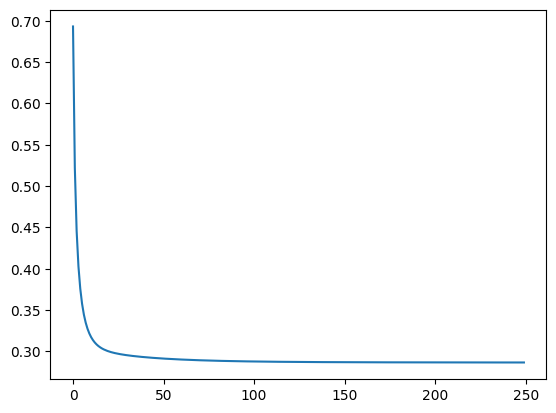

In [56]:
plt.plot(log_reg.losses)

In [57]:
from sklearn.datasets import load_diabetes
X, y = load_diabetes(return_X_y=True)

scaler = StandardScaler()

X_train_linear, X_test_linear, y_train_linear, y_test_linear = train_test_split(
    X, y, test_size=0.3, random_state=42
)

X_train_linear = scaler.fit_transform(X_train_linear)
X_test_linear = scaler.transform(X_test_linear)


In [67]:
alpha = 1
learning_rate = 0.001
num_iter = 20000
l1_ratio = 0.5
C=1

def print_and_save_info(model, weight, bias, loss, type='regression'):
    weights.append(weight)
    biases.append(bias)

    print(f"Weights of {model}:\n {weight}")
    print(f"Bias of {model}:\n {bias}")

    if type=='regression':    
        print(f"MSE of {model}: {loss}")
    print('-'* 50)

    return (weights, bias)

from sklearn.linear_model import LinearRegression as LR

sk_linreg = LR()
linreg = LinearRegression(num_iter=num_iter, lr=learning_rate)
lasso = Lasso(num_iter=num_iter, alpha=alpha, lr=learning_rate)
ridge = Ridge(num_iter=num_iter, alpha=alpha, lr=learning_rate)
elasticnet = ElasticNet(num_iter=num_iter, alpha=alpha, l1_ratio=l1_ratio, lr=learning_rate)

#learning regressions
models = (linreg, lasso, ridge, elasticnet, sk_linreg)
weights = []
biases = []
mean_squared_errors = []
for model in models:
    model.fit(X_train_linear, y_train_linear)
    predictions = model.predict(X_test_linear) 
    loss = mean_squared_error(y_test_linear, predictions)
    mean_squared_errors.append(loss)

    if not isinstance(model, LR):
        weights, bias = print_and_save_info(model, model.weights, model.bias, loss, type='regression')
    else:
        weights, bias = print_and_save_info(model, model.coef_, model.intercept_, loss, type='regression')

Weights of My LinearRegression:
 [  1.59353005 -12.31250725  26.81783784  18.35513462 -16.00632892
   2.99742787  -6.25805105  10.08320465  20.98089477   2.2755619 ]
Bias of My LinearRegression:
 153.90291262135213
MSE of My LinearRegression: 2827.176514853292
--------------------------------------------------
Stopped on iteration 11881
Weights of Lasso:
 [  1.04784428 -11.26327241  26.9002521   17.82531369  -9.40460839
   0.00023608  -9.75655854   6.39204197  19.12668267   2.09858527]
Bias of Lasso:
 153.90291261416138
MSE of Lasso: 2805.1836732605343
--------------------------------------------------
Stopped on iteration 4588
Weights of Ridge:
 [ 2.21340086 -4.57408757 15.55868933 10.72887675 -0.66893393 -1.47193422
 -8.01998447  6.10637076 10.73943886  5.26939315]
Bias of Ridge:
 153.88713032241512
MSE of Ridge: 2993.9375608849036
--------------------------------------------------
Stopped on iteration 4544
Weights of ElasticNet:
 [ 2.09420035 -4.39784045 15.49693603 10.63613985 -0.5

In [71]:
alpha = 1
learning_rate = 0.001
num_iter = 20000
l1_ratio = 0.5
C=1

def print_and_save_info(model, weight, bias, loss, type='regression'):
    weights.append(weight)
    biases.append(bias)

    print(f"Weights of {model}:\n {weight}")
    print(f"Bias of {model}:\n {bias}")

    if type=='regression':    
        print(f"MSE of {model}: {loss}")
    print('-'* 50)

    return (weights, bias)

from sklearn.linear_model import LinearRegression as LR

sk_linreg = LR()
linreg = LinearRegression(num_iter=num_iter, lr=learning_rate)
lasso = Lasso(num_iter=num_iter, alpha=alpha, lr=learning_rate)
ridge = Ridge(num_iter=num_iter, alpha=alpha, lr=learning_rate)
elasticnet = ElasticNet(num_iter=num_iter, alpha=alpha, l1_ratio=l1_ratio, lr=learning_rate)

#learning regressions
models = (linreg, lasso, ridge, elasticnet, sk_linreg)
weights = []
biases = []
mean_squared_errors = []
for model in models:
    model.fit(X_train_linear, y_train_linear)
    predictions = model.predict(X_test_linear) 
    loss = mean_squared_errorss(y_test_linear, predictions)
    mean_squared_errors.append(loss)

    if not isinstance(model, LR):
        weights, bias = print_and_save_info(model, model.weights, model.bias, loss, type='regression')
    else:
        weights, bias = print_and_save_info(model, model.coef_, model.intercept_, loss, type='regression')

Weights of My LinearRegression:
 [  1.59353005 -12.31250725  26.81783784  18.35513462 -16.00632892
   2.99742787  -6.25805105  10.08320465  20.98089477   2.2755619 ]
Bias of My LinearRegression:
 153.90291262135213
MSE of My LinearRegression: 2827.1765148532913
--------------------------------------------------
Stopped on iteration 11881
Weights of Lasso:
 [  1.04784428 -11.26327241  26.9002521   17.82531369  -9.40460839
   0.00023608  -9.75655854   6.39204197  19.12668267   2.09858527]
Bias of Lasso:
 153.90291261416138
MSE of Lasso: 2805.1836732605348
--------------------------------------------------
Stopped on iteration 4588
Weights of Ridge:
 [ 2.21340086 -4.57408757 15.55868933 10.72887675 -0.66893393 -1.47193422
 -8.01998447  6.10637076 10.73943886  5.26939315]
Bias of Ridge:
 153.88713032241512
MSE of Ridge: 2993.937560884903
--------------------------------------------------
Stopped on iteration 4544
Weights of ElasticNet:
 [ 2.09420035 -4.39784045 15.49693603 10.63613985 -0.5

In [59]:
C=1
CLASSIFICION_TYPE = 'classification'
from sklearn.linear_model import LogisticRegression as LogReg
from sklearn.svm import LinearSVC
sk_svm = LinearSVC()


sk_logreg = LogReg()
sk_svm = LinearSVC()
svm = SVM()

#learning regressions for classification
models_classification = (sk_logreg, sk_svm, svm)
weights_classification = []
biases_classification = []
log_loss_errors = []
for model in models_classification:
    model.fit(X_train, y_train)
    if not isinstance(model, (LinearSVC, SVM)):
        probs = model.predict_proba(X_test) 
        log_loss_errors.append(log_loss(y_test, probs))

    if isinstance(model, SVM):
        weights_classification, biases_classification = print_and_save_info(model, model.weights, model.bias, type=CLASSIFICION_TYPE)
    elif isinstance(model, LogReg):
        weights_classification, biases_classification = print_and_save_info(model, model.coef_, model.intercept_, type=CLASSIFICION_TYPE)
    else:
        weights_classification, biases_classification = print_and_save_info(model, model.coef_, model.intercept_, type=CLASSIFICION_TYPE)

Weights of LogisticRegression():
 [[-0.52213045 -0.53658554 -0.4979442  -0.56379712 -0.13460195  0.73756901
  -0.71136223 -0.76950335 -0.07628683  0.35316847 -1.20764229  0.26646079
  -0.74326528 -0.91757362 -0.18015681  0.6672991   0.13674384 -0.39552312
   0.36062184  0.43203303 -0.98028724 -1.32075819 -0.81310456 -0.9717533
  -0.91263827  0.09258914 -0.88766361 -0.95708094 -1.03704807 -0.24200346]]
Bias of LogisticRegression():
 [0.24347643]
--------------------------------------------------
Weights of LinearSVC():
 [[ 0.05040048 -0.15965045  0.02592237 -0.038795   -0.0987089   1.318816
  -0.42681424 -0.56367841 -0.0987502  -0.28322048 -0.88037946  0.23584314
   0.05440443 -0.86118107 -0.00086892 -0.03529707  0.59734822 -0.64883077
   0.21336209  0.27813183 -0.70558887 -0.7379269  -0.4505061  -0.99572279
  -0.37994537  0.13084107 -0.81097866 -0.12287391 -0.46121057 -0.11880289]]
Bias of LinearSVC():
 [-0.2217482]
--------------------------------------------------
Weights of SVM:
 [-

In [60]:
sk_logreg.coef_

array([[-0.52213045, -0.53658554, -0.4979442 , -0.56379712, -0.13460195,
         0.73756901, -0.71136223, -0.76950335, -0.07628683,  0.35316847,
        -1.20764229,  0.26646079, -0.74326528, -0.91757362, -0.18015681,
         0.6672991 ,  0.13674384, -0.39552312,  0.36062184,  0.43203303,
        -0.98028724, -1.32075819, -0.81310456, -0.9717533 , -0.91263827,
         0.09258914, -0.88766361, -0.95708094, -1.03704807, -0.24200346]])

In [61]:
import pandas as pd

df_regressions = pd.DataFrame({
    "models": models,
    "weights": weights,
    "bias": biases,
    'mse': mean_squared_errors
})


ValueError: All arrays must be of the same length

In [ ]:
df_regressions 


,models,weights,bias,mse
0,My LinearRegression,"[1.593530054694337, -12.312507253619435, 26.81...",153.902913,2827.176515
1,Lasso,"[1.0478442803095198, -11.263272414656837, 26.9...",153.902913,2805.183673
2,Ridge,"[2.213400857159948, -4.574087568115777, 15.558...",153.887130,2993.937561
3,ElasticNet,"[2.094200352675447, -4.397840448758698, 15.496...",153.885677,2999.477007
4,LinearRegression(),"[1.3524672442087808, -12.454268934391646, 26.2...",153.902913,2821.750981


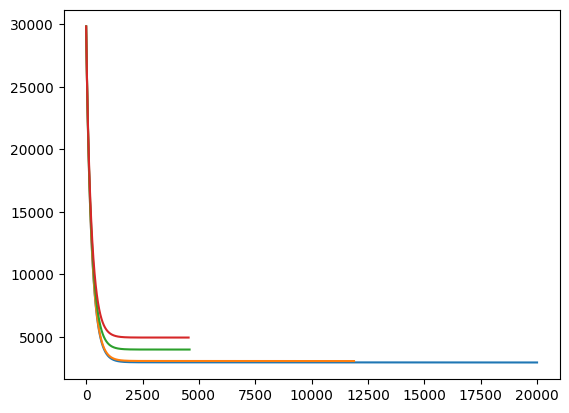

In [ ]:
for model in models[:-1]:
    print(plt.plot(model.losses))
